In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random

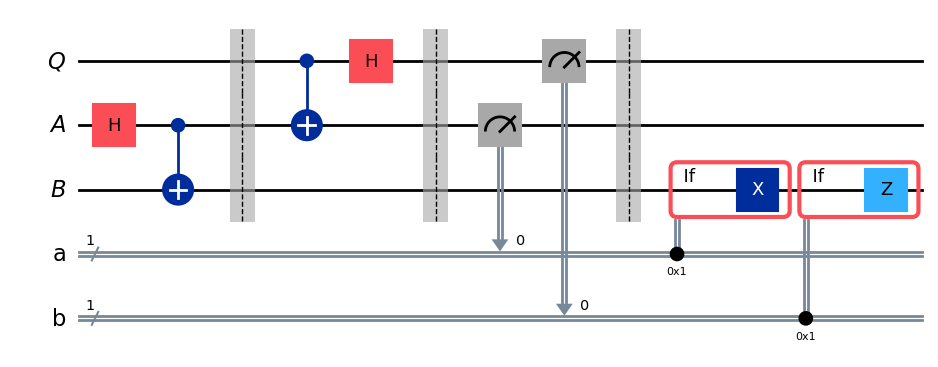

: 

In [ ]:
# Teleportation Protocol
qubit = QuantumRegister(1, "Q") # create a quantum register with 1 qubit
ebit0 = QuantumRegister(1, "A") # for Alice
ebit1 = QuantumRegister(1, "B") # for Bob
a = ClassicalRegister(1, "a") # Needed for -Alice-'s measurement result
b = ClassicalRegister(1, "b") # Needed for -Bob-'s measurement result

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b) # Entire Circuit

# Prepare ebit used for teleportation
protocol.h(ebit0) # "hadamard gate" for Alice's qubit
protocol.cx(ebit0, ebit1) # "CNOT" gate to entangle Alice's and Bob's qubits / control = ebit0, target = ebit1
protocol.barrier() 

# Alice's operations
protocol.cx(qubit, ebit0) #"CNOT" gate / control = qubit, target = ebit0
protocol.h(qubit) # "Hadamard" gate to put Alice
protocol.barrier() 

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)): # Check if Alice's measurement result is 1
    protocol.x(ebit1) # True = apply X gate to Bob's qubit
with protocol.if_test((b, 1)): # Check if Bob's measurement result is 1
    protocol.z(ebit1) # True = apply Z gate to Bob's qubit

display(protocol.draw(output="mpl"))

<IPython.core.display.Latex object>

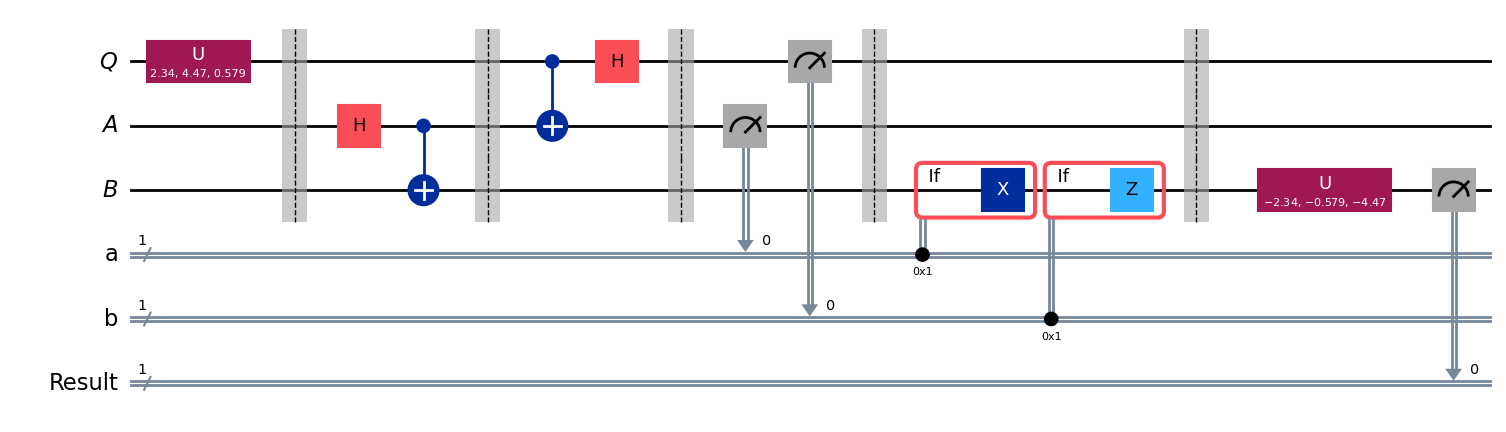

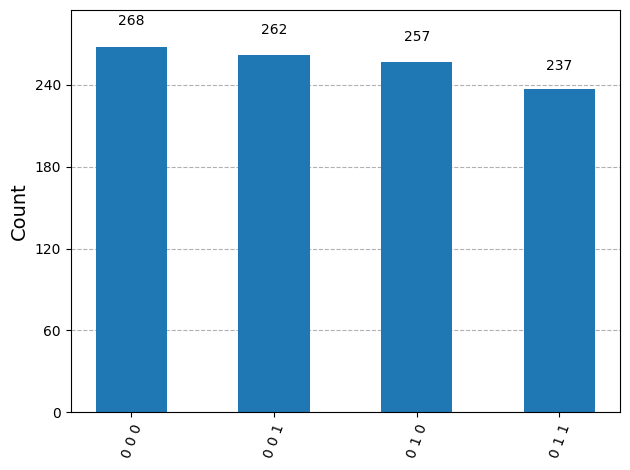

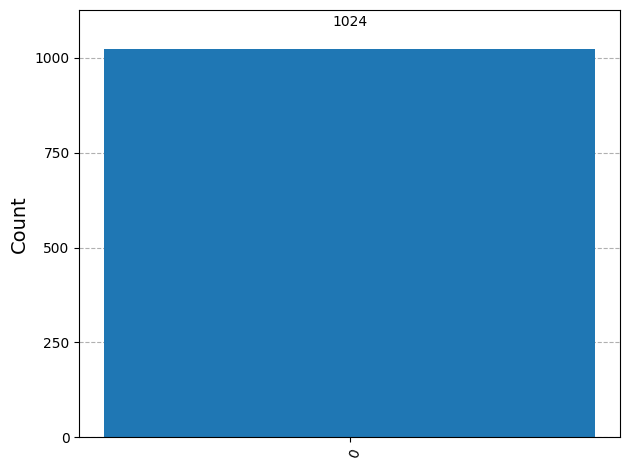

: 

In [ ]:
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

# Create a new circuit including the same bits and qubits used in the
# teleportation protocol.

test = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Start with the randomly selected gate on Q

test.append(random_gate, qubit) # append UGate to Q
test.barrier()

# Append the entire teleportation protocol from above.

test = test.compose(protocol) # test → protocol
test.barrier()

# Finally, apply the inverse of the random unitary to B and measure.

test.append(random_gate.inverse(), ebit1) # U * U^transpose = I → Why? : Identity means nothing has changed.
result = ClassicalRegister(1, "Result") # Create a classical register to store the measurement result
test.add_register(result) 
test.measure(ebit1, result) 

display(test.draw(output="mpl")) # Used Inverse : first value → - value / Second value → - Third value / Third value → - Second value

result = AerSimulator().run(test).result() #if |011> : result = 0 / b = 1 / a = 1 always read right to left.
statistics = result.get_counts()
display(plot_histogram(statistics))

filtered_statistics = marginal_distribution(statistics, [2]) # the qubits always starts with 0 = result → 100%
display(plot_histogram(filtered_statistics))

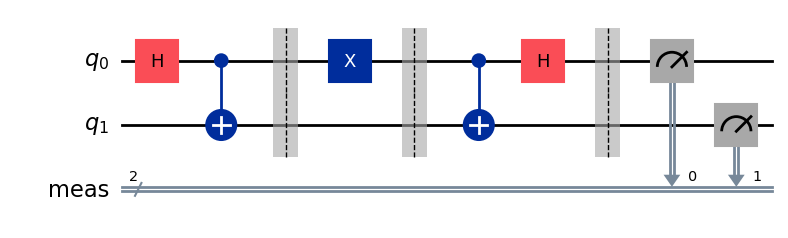

Measured 10 with frequency 1024


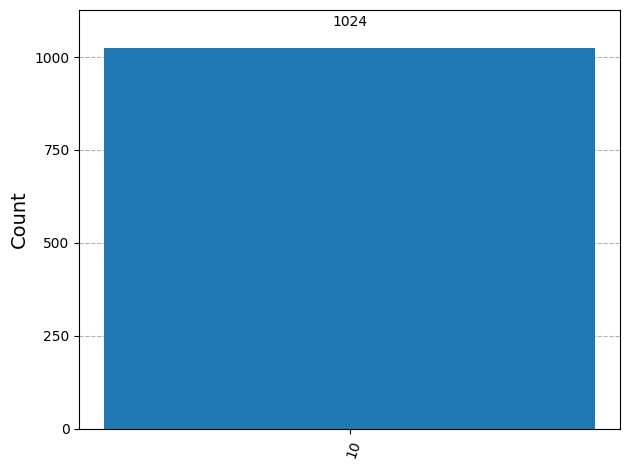

: 

In [ ]:
#Superdense Coding Protocol
c = "1"
d = "0"

protocol = QuantumCircuit(2)

# Prepare ebit used for superdense coding
protocol.h(0) # Hadamard gate
protocol.cx(0, 1) # CNOT gate / control = 0, target = 1
protocol.barrier()

# Alice's operations
if d == "1":
    protocol.z(0)
if c == "1":
    protocol.x(0)
protocol.barrier()

# Bob's actions
protocol.cx(0, 1)
protocol.h(0)
protocol.measure_all()

display(protocol.draw(output="mpl"))

result = AerSimulator().run(protocol).result() #Function, AerSimulator() → run(protocol) → result() : Run the circuit and get the result
statistics = result.get_counts() # Get the counts of the measurement results / this time → [01 : 1024]

for outcome, frequency in statistics.items(): #statistics.items() → [01 : 1024]
    print(f"Measured {outcome} with frequency {frequency}")

display(plot_histogram(statistics))

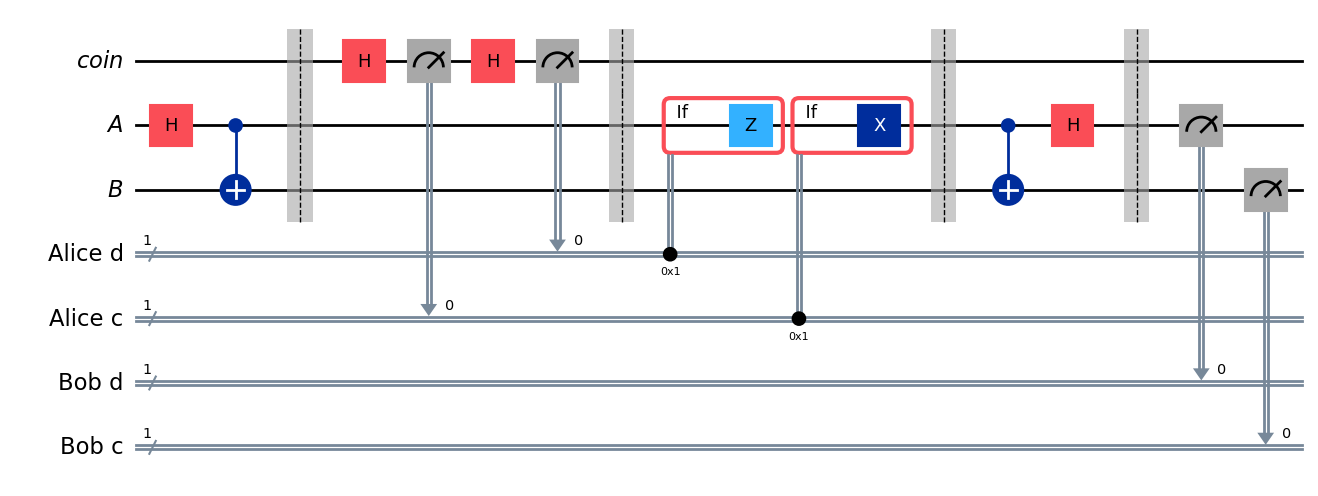

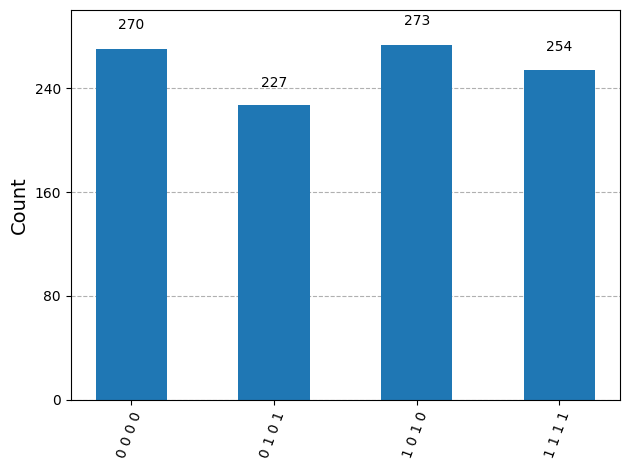

: 

In [ ]:
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1) #CNOT gate / control = ebit0, target = ebit1
test.barrier()

# Use the 'coin' qubit twice to generate Alice's bits c and d.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol runs, starting with Alice's actions, which depend
# on her bits.
with test.if_test((Alice_d, 1), label="Z"): # Check if Alice's d measurement result is 1 → apply Z gate
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"): # Check if Alice's c measurement result is 1 → apply X gate
    test.x(ebit0)
test.barrier()

# Bob's actions
test.cx(ebit0, ebit1) #Decodding
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c") #classical register for Bob's measurement result
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))

result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))